# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [47]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

np.random.seed(42)

dir_path = "../training_data"

names, labels, samples = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        samples.append(pd.read_csv(file_path, header=None))

### Project to 2D

Define function to project 3d data to 2d

In [48]:
from sklearn.decomposition import PCA

# Define function to project 3D data to 2D using PCA
def project_to_2d(data: pd.DataFrame|NDArray, keep_order: bool=True, keep_dims: bool=False) -> NDArray:
    
    # Convert data to numpy array if needed
    if isinstance(data, pd.DataFrame): data = data.to_numpy()

    # Apply PCA
    pca = PCA(n_components=data.shape[1]).fit(data)
    scores = pca.fit_transform(data)
    loadings = pca.components_ 

    # Find principal components that align best with the original axes
    order = np.argmax(np.abs(loadings), axis=0)[:(data.shape[1] if keep_dims else 2)]

    # Return reordered projected data
    return scores[:, order]

### Convert data to images

Define function to convert 2D coordinates to images

In [49]:
from typing import List

# Define a function to convert 2D/3D coordinates to images
def convert_to_image(data_projected: NDArray, size: tuple) -> NDArray: 

    # Initialize empty image
    width, height = size 
    image = np.zeros((height, width))

    # Center and scale the data to range [-1, 1]
    min_values, max_values = np.min(data_projected, axis=0), np.max(data_projected, axis=0)
    data_projected = data_projected - (min_values + max_values) / 2
    data_projected = data_projected / np.max(np.abs(data_projected)) # Scale to range [-1, 1]

    # Extract x and y data and scale to [0, N-1] (pixel coordinates)
    x_data, y_data = data_projected[:, 0], data_projected[:, 1] # Note: swap x and y for image coordinates
    x_data = x_data * ((width-1) / 2) + ((width-1) / 2)
    y_data = y_data * ((height-1) / 2) + ((height-1) / 2)

    # Compute floor and ceil values
    x_floor, x_ceil = np.floor(x_data).astype(int), np.ceil(x_data).astype(int)
    y_floor, y_ceil = np.floor(y_data).astype(int), np.ceil(y_data).astype(int)

    # Convert x, y data to pixels in an image
    image[y_floor, x_floor] += (1 - y_data % 1) * (1 - x_data % 1)
    image[y_ceil, x_ceil] += (y_data % 1) * (x_data % 1)
    image[y_floor, x_ceil] += (x_data % 1) * (1 - y_data % 1)
    image[y_ceil, x_floor] += (1 - x_data % 1) * (y_data % 1)

    # Clip the pixel values to range [0, 1]
    image = np.clip(image, 0, 1)  

    # Flip the image (so that it is not upside down)
    image = np.flip(image, 0)
    
    return image

### Preprocess the data

Project the 3d samples to 2d, convert 2d data to images and flatten the images to 1d vectors

In [50]:
# Project 3D samples to 2D
samples_2d = [project_to_2d(sample) for sample in samples]

# Convert 2D samples to images
image_size = (24, 24)
images = [convert_to_image(sample,image_size) for sample in samples_2d]

# Flatten the images to vectors for neural network classification
X = np.array([image.flatten() for image in images])

# Convert labels to a numpy array
y = np.array(labels)

Visualize preprocessed images

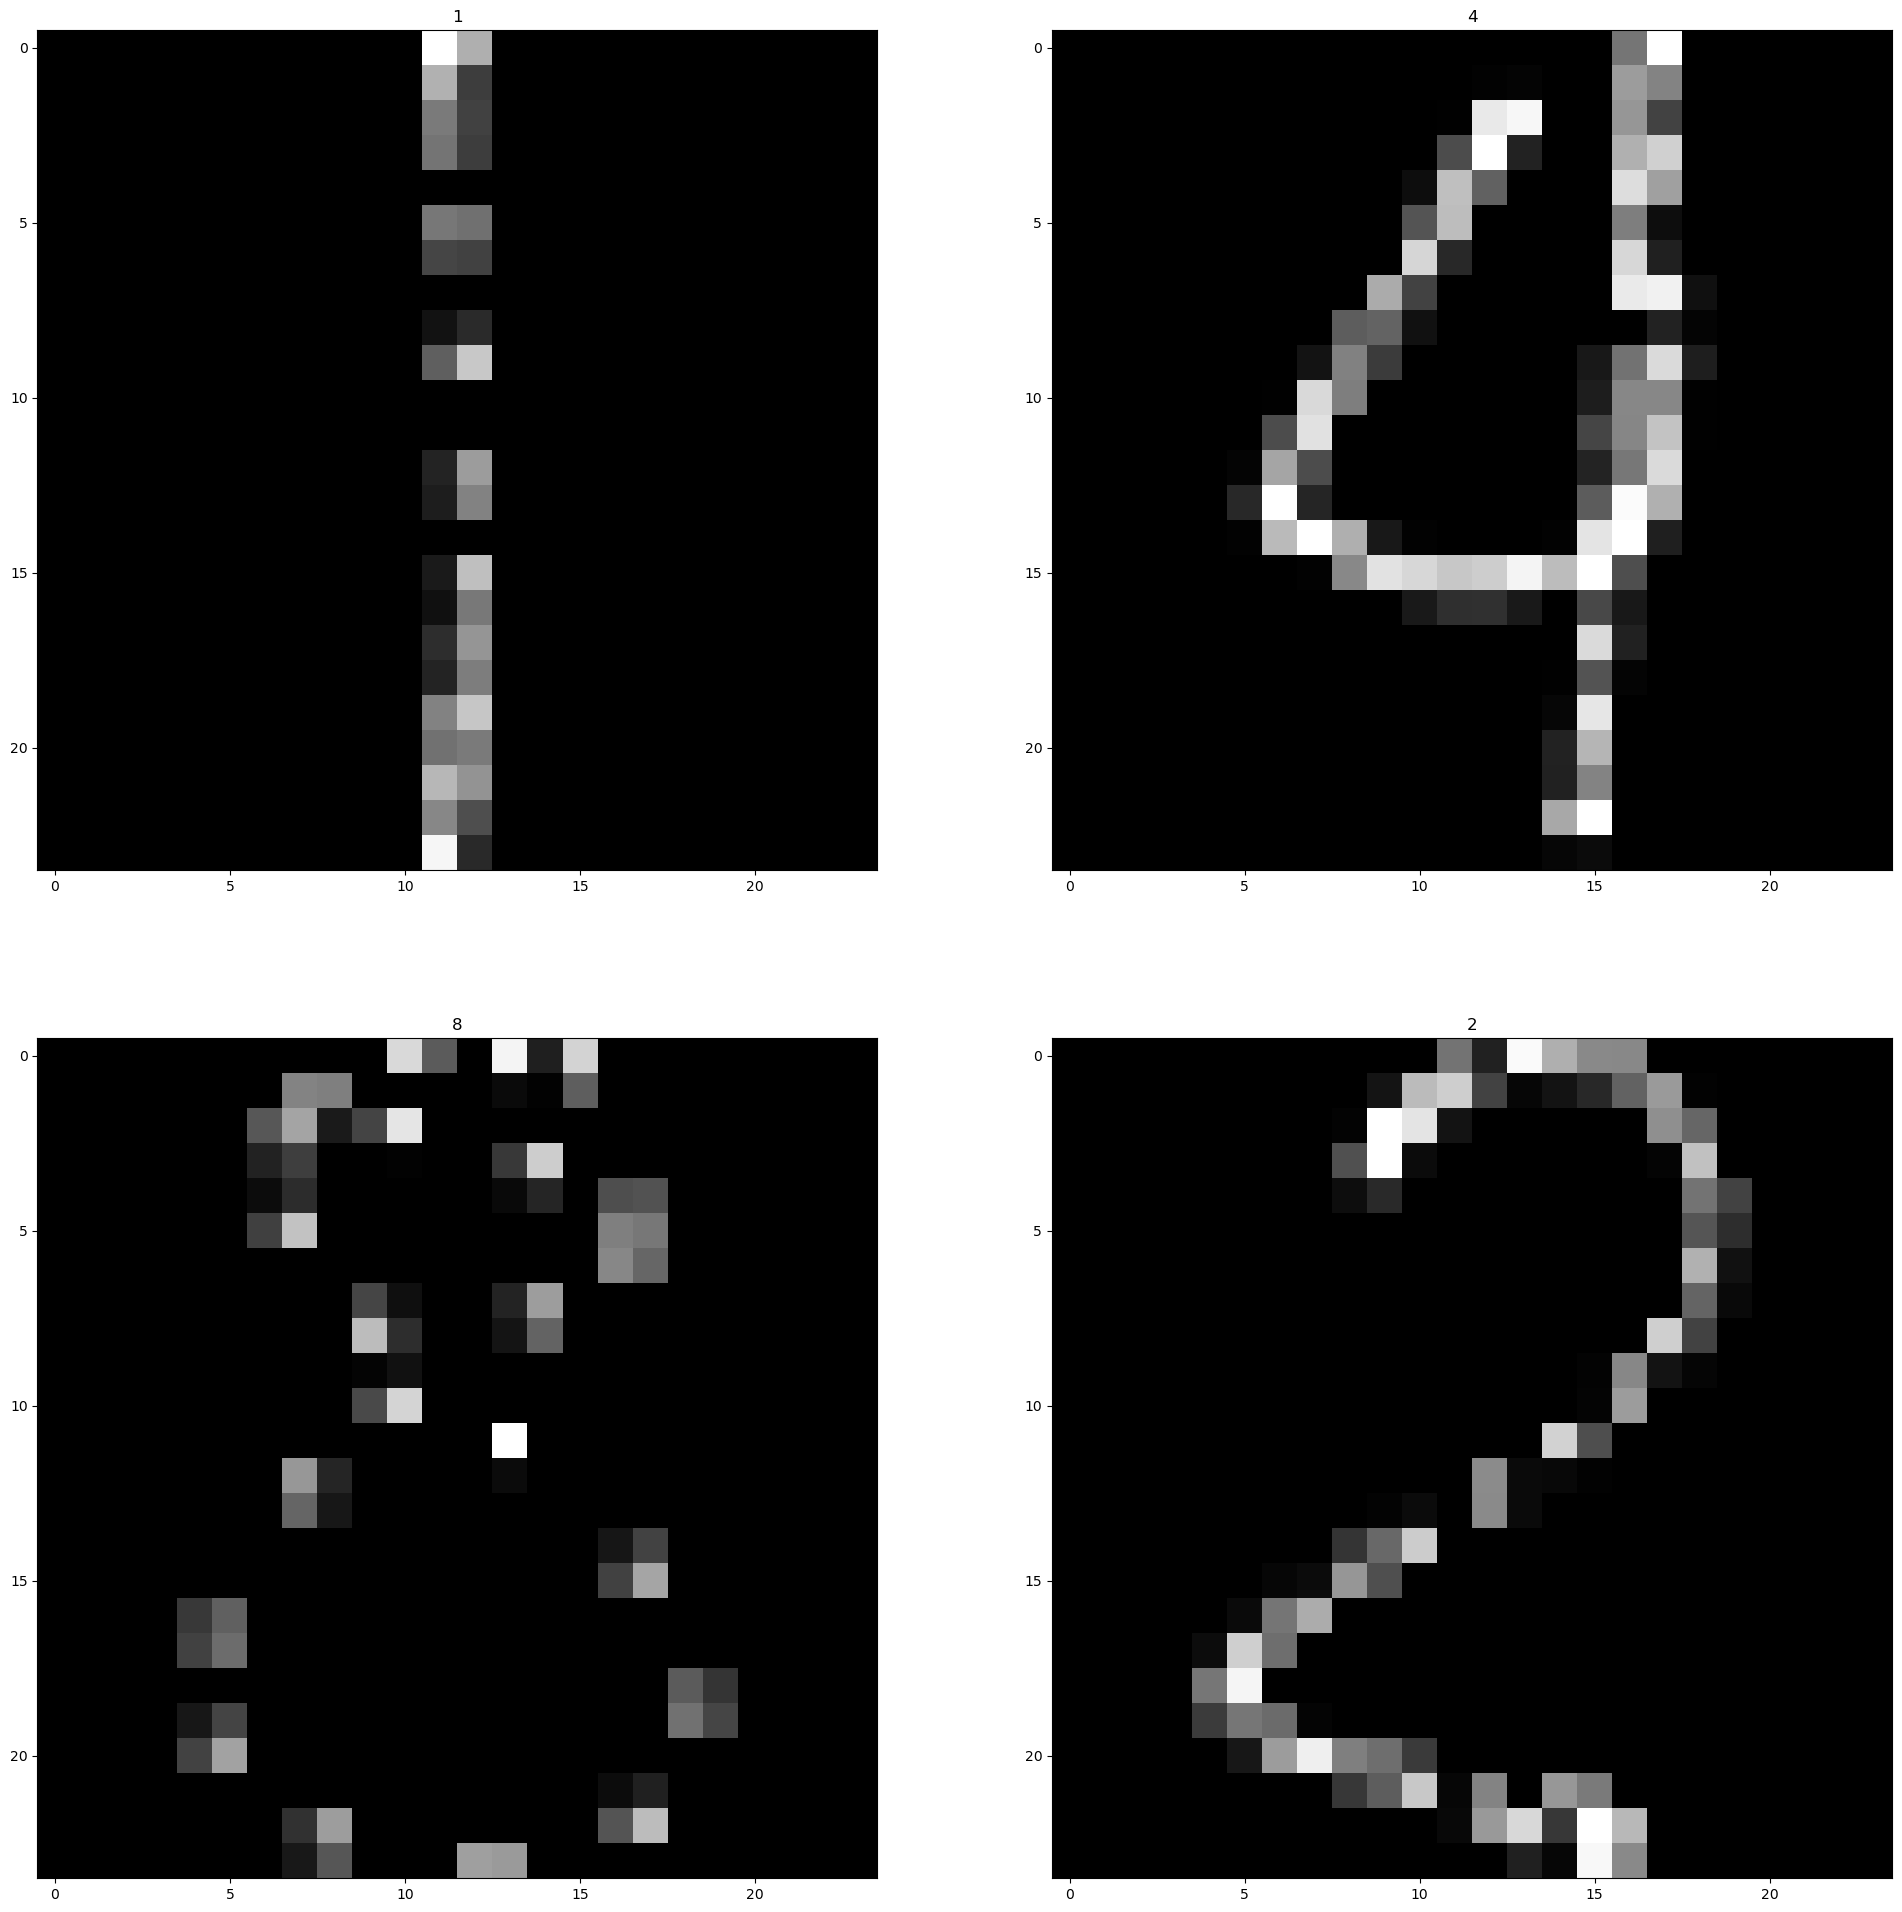

In [51]:
# Select random images
index = np.random.choice(len(images), 4)
selected_images = [images[i] for i in index]
selected_labels = [labels[i] for i in index]

fig, axes = plt.subplots(2, 2, figsize=(24, 24))
axes = axes.flatten()
for i, (image, label) in enumerate(zip(selected_images, selected_labels)): 
    axes[i].imshow(image, cmap='Grays_r')
    axes[i].set_title(label)
plt.show()

___

## Training the model 

### Split data to training and test sets

In [52]:
from neural_network import *
from sklearn.model_selection import train_test_split

# Flatten the samples
X_flat = np.array([x.flatten() for x in X])

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Split the data to training/validation and test sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_encoded, test_size=0.20, stratify=y, random_state=42)

### Define model

In [53]:
from numpy.random import uniform

model = NeuralNetworkClassifier(
    Dense(uniform(-0.1, 0.1, size=(X_flat.shape[1], 256)), np.zeros(256), ReLU),
    Dense(uniform(-0.1, 0.1, size=(256, 128)), np.zeros(128), ReLU), 
    Dense(uniform(-0.1, 0.1, size=(128, 10)), np.zeros(10), Softmax)
)

### Train the model 

  1%|          | 123/10000 [00:04<05:30, 29.87it/s]


Model accuracy (training set): 98 %
Model accuracy (test set): 90 %


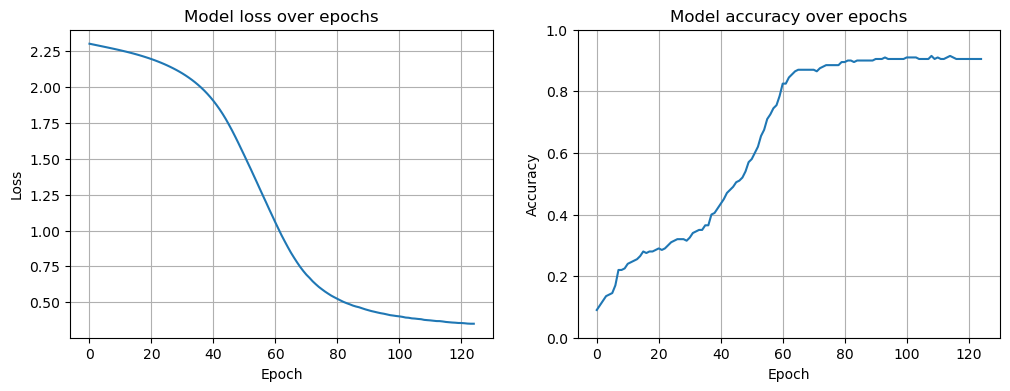

In [54]:
import matplotlib.pyplot as plt

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.1, 1e-4, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

Further training

  1%|          | 83/10000 [00:02<04:53, 33.75it/s]


Model accuracy (training set): 99 %
Model accuracy (test set): 91 %


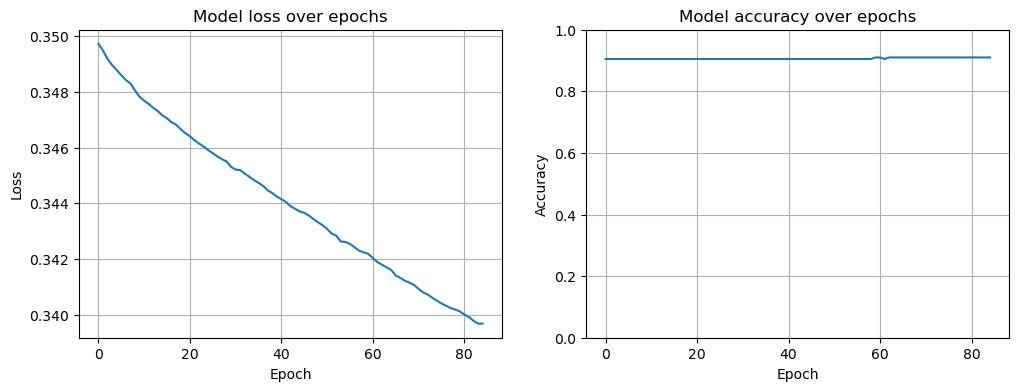

In [55]:
# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 64, 0.01, 1e-5, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Train the model  
loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
    criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
    tol=tol, min_loss=min_loss, verbose=True
)

# Visualize training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Measure accuracy
y_pred = model.forward(X_train)
print(f"Model accuracy (training set): {accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

# Measure accuracy
y_pred = model.forward(X_test)
print(f"Model accuracy (test set): {accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))*100:.0f} %")

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [58]:
from typing import Callable

def preprocess(samples: list[NDArray|pd.DataFrame], image_size=image_size) -> tuple[NDArray, NDArray]: 
    samples_2d = [project_to_2d(sample) for sample in samples]
    images = [convert_to_image(sample, image_size) for sample in samples_2d]
    return np.array([image.flatten() for image in images])

def classify(samples: List[NDArray|pd.DataFrame], predict: Callable, preprocess: Callable) -> NDArray: 

    # Preprocess the samples
    X = preprocess(samples)
    
    # Predict the classes of the samples
    return predict(X)

In [59]:
# Select random test set 
index = np.random.choice(len(samples), 100).astype(int)
test_datas, test_labels = [samples[i] for i in index], [labels[i] for i in index]

# Predict the test set using the classify-function
predicted_labels = classify(test_datas, model.predict, preprocess)

# Measure prediction accuracy
print(f"Classification accuracy: {accuracy_score(test_labels, predicted_labels)*100:.0f} %")

Classification accuracy: 95 %
